The Goal: Predict how many bicycles will be rented out in a city during any given hour.

In [59]:
import pandas as pd
import urllib.request
import zipfile

# 1. Download and extract the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip"
urllib.request.urlretrieve(url, "bike_data.zip")

with zipfile.ZipFile("bike_data.zip", 'r') as zip_ref:
    zip_ref.extractall("bike_data")

# 2. Load the hourly data
df = pd.read_csv("bike_data/hour.csv")

# Let's see what we are working with
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [60]:
# 1. Convert the text column into true 'datetime' objects
df['dteday'] = pd.to_datetime(df['dteday'])

# 2. Extract standard time components
df['Month'] = df['dteday'].dt.month
df['DayOfWeek'] = df['dteday'].dt.dayofweek # 0 = Monday, 6 = Sunday
df['Year'] = df['dteday'].dt.year

# 3. Create custom human-behavior features
# If the DayOfWeek is 5 (Saturday) or 6 (Sunday), mark it as a weekend (1). Otherwise, 0.
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# 4. Create a "Rush Hour" feature
# People rent bikes to commute. We'll define rush hour as 7-9 AM and 5-7 PM on weekdays.
def is_rush_hour(hour, is_weekend):
    if is_weekend == 0 and (7 <= hour <= 9 or 17 <= hour <= 19):
        return 1
    return 0

# Apply the logic across the dataframe using the existing 'hr' (hour) column
df['Is_RushHour'] = df.apply(lambda row: is_rush_hour(row['hr'], row['Is_Weekend']), axis=1)

# Drop columns we no longer need (like the original date text and some redundant ID columns)
df = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)

print("Time features successfully engineered!")
display(df[['hr', 'DayOfWeek', 'Is_Weekend', 'Is_RushHour', 'cnt']].head(15))

Time features successfully engineered!


,hr,DayOfWeek,Is_Weekend,Is_RushHour,cnt
0,0,5,1,0,16
1,1,5,1,0,40
2,2,5,1,0,32
3,3,5,1,0,13
4,4,5,1,0,1
5,5,5,1,0,1
6,6,5,1,0,2
7,7,5,1,0,3
8,8,5,1,0,8
9,9,5,1,0,14


/tmp/ipykernel_1073/3673695848.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weathersit', y='cnt', data=df, palette='Set2')


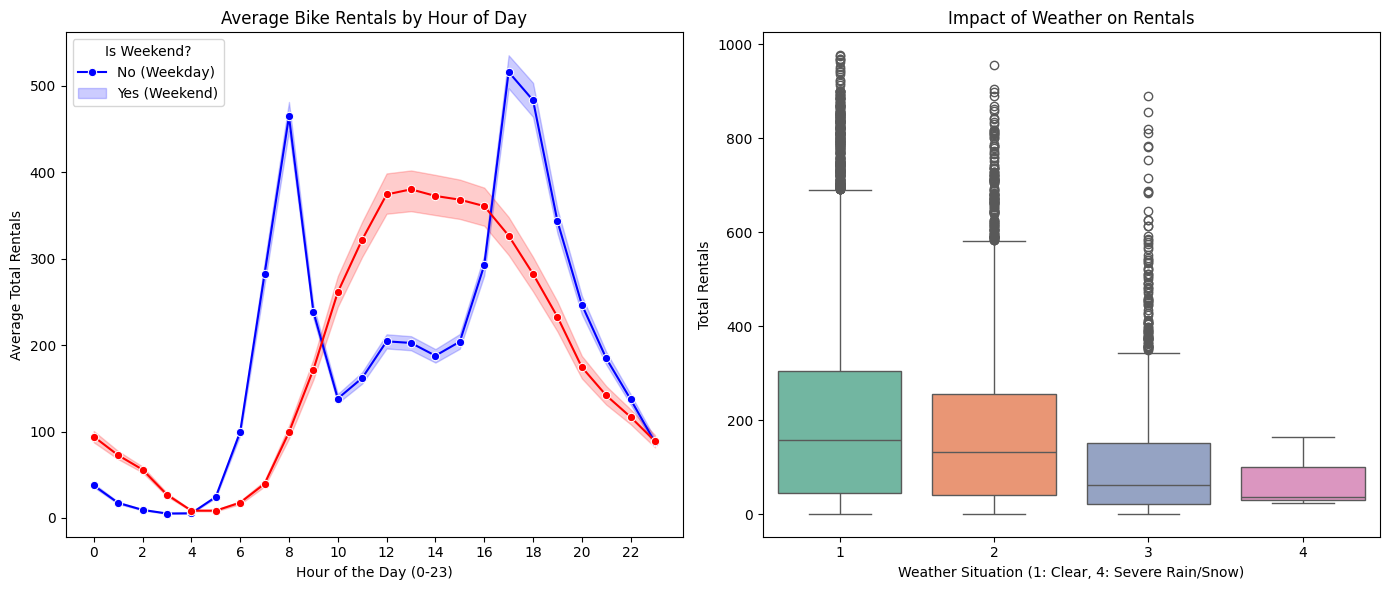

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Plot 1: Rentals by Hour (Split by Weekend vs. Weekday)
plt.subplot(1, 2, 1)
sns.lineplot(x='hr', y='cnt', hue='Is_Weekend', data=df, marker='o', palette=['b', 'r'])
plt.title('Average Bike Rentals by Hour of Day')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Average Total Rentals')
plt.xticks(range(0, 24, 2))
plt.legend(title='Is Weekend?', labels=['No (Weekday)', 'Yes (Weekend)'])

# Plot 2: How Weather affects Rentals
plt.subplot(1, 2, 2)
sns.boxplot(x='weathersit', y='cnt', data=df, palette='Set2')
plt.title('Impact of Weather on Rentals')
plt.xlabel('Weather Situation (1: Clear, 4: Severe Rain/Snow)')
plt.ylabel('Total Rentals')

plt.tight_layout()
plt.show()

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df.drop('cnt', axis=1)
y = df['cnt']

# We only want to scale the continuous weather variables, not our binary (0/1) time features
columns_to_scale = ['temp', 'atemp', 'hum', 'windspeed']
scaler = StandardScaler()
X[columns_to_scale] = scaler.fit_transform(X[columns_to_scale])

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (13903, 17)
Testing data shape: (3476, 17)


In [63]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize and train the model
# (We will use 100 trees, which is a solid default)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Random Forest Performance ---")
print(f"MAE:  {mae:.2f} bikes")
print(f"RMSE: {rmse:.2f} bikes")
print(f"R²:   {r2:.4f}")

--- Random Forest Performance ---
MAE:  24.41 bikes
RMSE: 40.82 bikes
R²:   0.9474


/tmp/ipykernel_1073/538128787.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


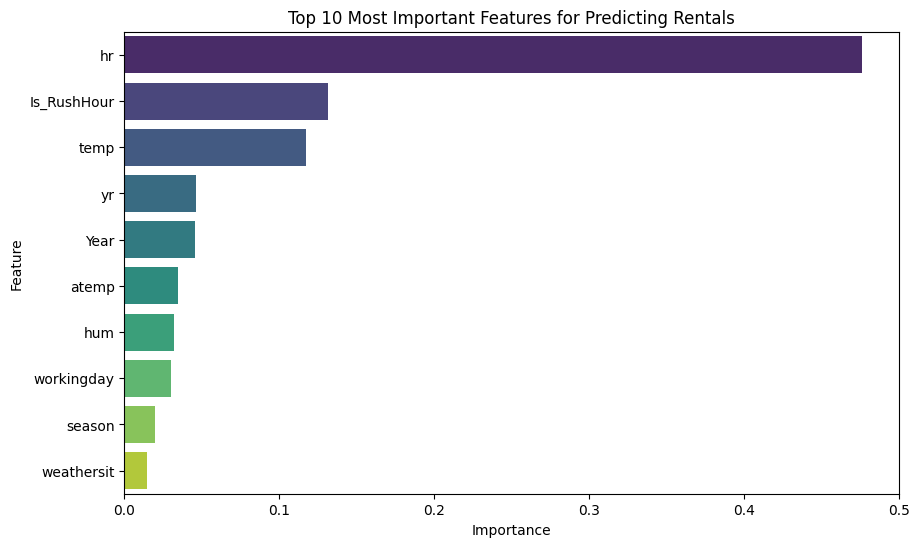

In [64]:
# Extract feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features for Predicting Rentals')
plt.show()

In [65]:
from sklearn.model_selection import cross_val_score

# Run 5-fold cross-validation
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2', n_jobs=-1)

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Average CV R² Score: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")

Cross-Validation R² Scores: [0.75386884 0.87127317 0.74901956 0.88490302 0.89900501]
Average CV R² Score: 0.8316 (± 0.0661)


In [77]:
def predict_bike_demand(hour, month, day_of_week, temp_celsius, humidity, weather_situation):
    """
    Simulates predicting bike demand for a specific future hour.
    """
    # 1. Recreate our engineered features
    is_weekend = 1 if day_of_week >= 5 else 0
    rush_hour = is_rush_hour(hour, is_weekend)

    # 2. Convert Celsius to the normalized scale the model expects
    # The original dataset normalized temp by dividing by 41
    norm_temp = temp_celsius / 41.0

    # 3. Create a single row DataFrame matching the exact columns of X_train
    # (Setting defaults for features we aren't heavily focusing on in this simple function)
    input_data = pd.DataFrame({
        'season': [3],               # Fall
        'yr': [1],                   # Year 2
        'mnth': [month],             # User input
        'hr': [hour],                # User input
        'holiday': [0],              # Assume not a holiday
        'weekday': [day_of_week],    # User input
        'workingday': [1 if is_weekend == 0 else 0],
        'weathersit': [weather_situation], # User input (1=Clear, 4=Bad)
        'temp': [norm_temp],         # User input
        'atemp': [norm_temp],
        'hum': [humidity / 100.0],   # User input
        'windspeed': [0.2],          # Default mild wind
        'Month': [month],
        'DayOfWeek': [day_of_week],
        'Year': [2012],
        'Is_Weekend': [is_weekend],
        'Is_RushHour': [rush_hour]
    })

    # We must apply the same scaler to the continuous features
    input_data[columns_to_scale] = scaler.transform(input_data[columns_to_scale])

    # Make the prediction
    prediction = rf_model.predict(input_data)[0]
    return int(prediction)

# --- Let's test it! ---
# Scenario 1: Tuesday morning rush hour, clear weather, 25°C
scenario_1 = predict_bike_demand(hour=8, month=6, day_of_week=1, temp_celsius=25, humidity=50, weather_situation=1)

# Scenario 2: Sunday morning, same weather
scenario_2 = predict_bike_demand(hour=8, month=6, day_of_week=6, temp_celsius=25, humidity=50, weather_situation=1)

print(f"Predicted Demand for Tuesday 8:00 AM: {scenario_1} bikes")
print(f"Predicted Demand for Sunday 8:00 AM:  {scenario_2} bikes")

Predicted Demand for Tuesday 8:00 AM: 614 bikes
Predicted Demand for Sunday 8:00 AM:  605 bikes


In [78]:
import joblib

# Save the model and scaler to the Colab environment
joblib.dump(rf_model, 'bike_rf_model.pkl')
joblib.dump(scaler, 'bike_scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [79]:
!pip install -q streamlit
!npm install localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 24.6 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
added 22 packages in 3s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹npm notice
npm notice New major version of npm available! 10.8.2 -> 11.13.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.13.0
npm notice To update run: npm install -g npm@11.13.0
npm notice
⠹

In [80]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# 1. Load the saved model and scaler
model = joblib.load('bike_rf_model.pkl')
scaler = joblib.load('bike_scaler.pkl')

# Helper function for rush hour
def is_rush_hour(hour, is_weekend):
    if is_weekend == 0 and (7 <= hour <= 9 or 17 <= hour <= 19):
        return 1
    return 0

# 2. Build the Web App UI
st.title("🚲 City Bike Demand Predictor")
st.write("Adjust the sliders below to predict how many bikes will be rented during a specific hour.")

col1, col2 = st.columns(2)

with col1:
    hour = st.slider("Hour of the Day (0-23)", 0, 23, 8)
    day_of_week = st.selectbox("Day of the Week", [0, 1, 2, 3, 4, 5, 6], format_func=lambda x: ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'][x])
    month = st.slider("Month (1-12)", 1, 12, 6)

with col2:
    temp_c = st.slider("Temperature (°C)", -10, 40, 25)
    humidity = st.slider("Humidity (%)", 0, 100, 50)
    weather_sit = st.selectbox("Weather Condition", [1, 2, 3, 4], format_func=lambda x: ['Clear/Partly Cloudy', 'Misty/Cloudy', 'Light Rain/Snow', 'Heavy Rain/Snow'][x-1])

# 3. Process the Inputs
if st.button("Predict Bike Demand"):
    # Recreate the datetime logic
    is_weekend = 1 if day_of_week >= 5 else 0
    rush_hour = is_rush_hour(hour, is_weekend)
    norm_temp = temp_c / 41.0

    # Create the exact DataFrame structure the model expects
    input_data = pd.DataFrame({
        'season': [3],
        'yr': [1],
        'mnth': [month],
        'hr': [hour],
        'holiday': [0],
        'weekday': [day_of_week],
        'workingday': [1 if is_weekend == 0 else 0],
        'weathersit': [weather_sit],
        'temp': [norm_temp],
        'atemp': [norm_temp],
        'hum': [humidity / 100.0],
        'windspeed': [0.2],
        'Month': [month],
        'DayOfWeek': [day_of_week],
        'Year': [2012],
        'Is_Weekend': [is_weekend],
        'Is_RushHour': [rush_hour]
    })

    # Scale the continuous variables
    columns_to_scale = ['temp', 'atemp', 'hum', 'windspeed']
    input_data[columns_to_scale] = scaler.transform(input_data[columns_to_scale])

    # Predict
    prediction = model.predict(input_data)[0]

    st.success(f"🔥 Predicted Demand: **{int(prediction)} bikes**")

Writing app.py


In [81]:
import urllib
print("Password/Enpoint IP for localtunnel is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))

Password/Enpoint IP for localtunnel is: 34.106.44.212


In [82]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹your url is: https://lemon-poets-juggle.loca.lt



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.44.212:8501

  Stopping...
^C
